# Example 01 — MPC with Certificate-based Terminal Set

**System**: Double integrator $\dot{x}_1 = x_2,\; \dot{x}_2 = u$

**Goal**: Drive the output $y = x_1$ into the target set $\mathcal{X}^r = \{x : x_1^2 \le 0.01\}$ while remaining in the safe set $\mathcal{X}_S = \{x : x_1^2 \le 1\}$.

**MPC Terminal Set**: The zero super-level set of the reach-avoid certificate `certificate_opt`, i.e., $\{x : V(x) \ge 0\}$.  
This guarantees that once the MPC drives the state into the certified region, the certificate-based controller can complete the reach-avoid task, providing a composable safety and convergence guarantee.


In [113]:
# ── Imports & load computed certificate / controller ─────────────────────────
import sympy as sp
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
from functional import BetterColor

from sop_bounded_control_ex1_debug_20260312_143546 import (
    u_opt as u_opt_list,
    certificate_opt,
)

x1_sym, x2_sym = sp.symbols("x1 x2")
y1_sym = sp.symbols("y1", real=True)

u_opt_sym = sp.Matrix(u_opt_list)

print("Certificate V(x1, x2):")
print(certificate_opt)
print("\nNo-MPC controller u(x1, x2):")
print(u_opt_sym[0])
print(f"\nCasADi version: {ca.__version__}")

Certificate V(x1, x2):
-x1**2 - (-0.024408*x1**4 + 0.50236*x1**3 - 0.17979*x1**2 + 1.2929*x1 + x2 + 0.0039964)**2/20 + 1

No-MPC controller u(x1, x2):
-9.27542283912569e-5*x1**4 + 0.00190904679509308*x1**3 - 0.000683230200035401*x1**2 - 19.9950867772088*x1 + x2*(0.097632*x1**3 - 1.50708*x1**2 + 0.35958*x1 - 1.2929) + 8762565106153311*x2/2305843009213693952 + 1.51869468347599e-5

CasADi version: 3.7.2


In [114]:
# ── System & set definitions ─────────────────────────────────────────────────
f_sym = sp.Matrix([x2_sym, 0])
g_sym = sp.Matrix([[0], [1]])
hx_sym = sp.Matrix([x1_sym])  # output map

safe_set_sym = 1 - y1_sym**2  # psi(y) >= 0  inside safe set
target_set_sym = y1_sym**2 - 0.01  # phi(y) <= 0  inside target set

# Substitute output map to get set expressions in x-coordinates
safe_set_x_sym = safe_set_sym.subs({y1_sym: hx_sym[0]})
target_set_x_sym = target_set_sym.subs({y1_sym: hx_sym[0]})

certificate_func = sp.lambdify([x1_sym, x2_sym], certificate_opt, "numpy")
target_set_x_func = sp.lambdify([x1_sym, x2_sym], target_set_x_sym, "numpy")
u_nompc_func = sp.lambdify([x1_sym, x2_sym], u_opt_sym[0], "numpy")

print("Safe set  (x):  ", safe_set_x_sym, ">= 0")
print("Target set (x): ", target_set_x_sym, "<= 0")

Safe set  (x):   1 - x1**2 >= 0
Target set (x):  x1**2 - 0.01 <= 0


In [115]:
# ── Sample valid initial states (inside certificate superlevel set, outside target) ──
N_samples = 10000
np.random.seed(4)

lower_bound = np.array([-1.0, -10.0])
upper_bound = np.array([1.0, 10.0])
x_samples = np.random.random((2, N_samples)) * (upper_bound - lower_bound).reshape(
    -1, 1
) + lower_bound.reshape(-1, 1)

cert_vals = certificate_func(x_samples[0], x_samples[1])
target_vals = target_set_x_func(x_samples[0], x_samples[1])

valid_idx = np.where((cert_vals >= 0) & (target_vals > 0))[0]
x_samples_valid = x_samples[:, valid_idx][
    :, :50
]  # keep first 50 valid samples for visualization

print(f"Total valid samples: {valid_idx.shape[0]},  using: {x_samples_valid.shape[1]}")

Total valid samples: 3073,  using: 50


In [116]:
# ── Sympy → CasADi symbolic expression converter ────────────────────────────
def sympy2casadi(expr, sym_map):
    """Recursively convert a sympy expression to a CasADi expression."""
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
        ),
    ):
        return float(expr)
    elif isinstance(expr, sp.Symbol):
        return sym_map[expr]
    elif isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        result = 1.0
        for a in expr.args:
            result = result * sympy2casadi(a, sym_map)
        return result
    elif isinstance(expr, sp.Pow):
        base = sympy2casadi(expr.args[0], sym_map)
        exp = sympy2casadi(expr.args[1], sym_map)
        return base**exp
    elif isinstance(expr, sp.Number):  # catch-all for other numeric types
        return float(expr)
    else:
        raise ValueError(f"Unsupported sympy type: {type(expr)}  —  {expr}")


# Shared CasADi symbols for conversion
ca_x1_s = ca.SX.sym("x1")
ca_x2_s = ca.SX.sym("x2")

# CasADi function for the reach-avoid certificate V(x1, x2)
cert_ca_expr = sympy2casadi(certificate_opt, {x1_sym: ca_x1_s, x2_sym: ca_x2_s})
cert_ca_func = ca.Function("cert", [ca_x1_s, ca_x2_s], [cert_ca_expr])

# CasADi function for the safe set: psi(x1, x2) = 1 - x1^2 >= 0
safe_set_ca_expr = sympy2casadi(safe_set_x_sym, {x1_sym: ca_x1_s, x2_sym: ca_x2_s})
safe_set_ca_func = ca.Function("safe_set", [ca_x1_s, ca_x2_s], [safe_set_ca_expr])

# Sanity checks
test = np.array([0.3, 1.5])
v_sp = float(certificate_opt.subs({x1_sym: test[0], x2_sym: test[1]}))
v_ca = float(cert_ca_func(test[0], test[1]))
print(f"Certificate at {test}:  sympy = {v_sp:.8f},  casadi = {v_ca:.8f}")
assert abs(v_sp - v_ca) < 1e-8, "Certificate conversion mismatch!"

s_sp = float(safe_set_x_sym.subs({x1_sym: test[0], x2_sym: test[1]}))
s_ca = float(safe_set_ca_func(test[0], test[1]))
print(f"Safe set  at {test}:  sympy = {s_sp:.8f},  casadi = {s_ca:.8f}")
assert abs(s_sp - s_ca) < 1e-8, "Safe set conversion mismatch!"

print("All conversions verified OK.")

Certificate at [0.3 1.5]:  sympy = 0.73157426,  casadi = 0.73157426
Safe set  at [0.3 1.5]:  sympy = 0.91000000,  casadi = 0.91000000
All conversions verified OK.


In [117]:
# ── MPC problem formulation ──────────────────────────────────────────────────
# ── Parameters ───────────────────────────────────────────────────────────────
nx = 2  # state dim:   [x1, x2]
nu = 1  # control dim: [u]
dt = 0.01  # MPC discretisation step (s)
N = 20  # prediction horizon (steps → 0.2 s look-ahead)
u_max = 20.0  # control bound  |u| <= u_max

# Cost weights
Q_cost = np.diag([10, 1])  # stage state cost  x_k^T Q x_k
Qf_cost = np.diag([1, 1])  # terminal state cost  x_N^T Qf x_N
R_cost = np.array([[0.01]])  # control magnitude penalty  u_k^T R u_k

# ── CasADi symbolic system ───────────────────────────────────────────────────
x_ca = ca.SX.sym("x", nx)
u_ca = ca.SX.sym("u", nu)

xdot = ca.vertcat(x_ca[1], u_ca[0])  # dx1/dt = x2,  dx2/dt = u
f_ca = ca.Function("f", [x_ca, u_ca], [xdot])

# RK4 integrator (one step of length dt)
k1 = f_ca(x_ca, u_ca)
k2 = f_ca(x_ca + dt / 2 * k1, u_ca)
k3 = f_ca(x_ca + dt / 2 * k2, u_ca)
k4 = f_ca(x_ca + dt * k3, u_ca)
x_next_expr = x_ca + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
F_ca = ca.Function("F", [x_ca, u_ca], [x_next_expr])

# ── Opti NLP ─────────────────────────────────────────────────────────────────
opti = ca.Opti()

X_var = opti.variable(nx, N + 1)  # state trajectory
U_var = opti.variable(nu, N)  # control sequence
x0_param = opti.parameter(nx)  # current state (set at run-time)

# ── Cost: stage state + stage control + terminal state ────────────────────────
cost = 0

for k in range(N):
    cost += X_var[:, k].T @ Q_cost @ X_var[:, k]  # stage state cost
    cost += U_var[:, k].T @ R_cost @ U_var[:, k]  # control magnitude cost

cost += X_var[:, N].T @ Qf_cost @ X_var[:, N]  # terminal state cost

opti.minimize(cost)

# ── Constraints ──────────────────────────────────────────────────────────────
opti.subject_to(X_var[:, 0] == x0_param)  # initial condition
for k in range(N):
    opti.subject_to(X_var[:, k + 1] == F_ca(X_var[:, k], U_var[:, k]))  # dynamics

opti.subject_to(opti.bounded(-u_max, U_var[0, :], u_max))  # control bounds

# Safe set constraint: psi(x_k) >= 0 for all k in horizon
for k in range(N + 1):
    opti.subject_to(safe_set_ca_func(X_var[0, k], X_var[1, k]) >= 0)

# ── Terminal set: certificate_opt(x_N) >= 0 ──────────────────────────────────
terminal_cert = cert_ca_func(X_var[0, N], X_var[1, N])
opti.subject_to(terminal_cert >= 0)

# ── Solver ────────────────────────────────────────────────────────────────────
opts = {"ipopt.print_level": 0, "print_time": False, "ipopt.max_iter": 600}
opti.solver("ipopt", opts)

print("MPC NLP built successfully.")
print(f"  nx={nx}, nu={nu}, N={N}, dt={dt} s  (horizon = {N * dt:.2f} s)")
print(f"  Control bound:  |u| <= {u_max}")
print(f"  Stage cost:     x_k^T Q x_k   (Q  = diag{np.diag(Q_cost).tolist()})")
print(f"  Terminal cost:  x_N^T Qf x_N  (Qf = diag{np.diag(Qf_cost).tolist()})")
print(f"  Control cost:   u_k^T R u_k   (R  = {float(R_cost[0, 0])})")
print(f"  Terminal set:   V(x_N) >= 0   (zero super-level set of certificate_opt)")

MPC NLP built successfully.
  nx=2, nu=1, N=20, dt=0.01 s  (horizon = 0.20 s)
  Control bound:  |u| <= 20.0
  Stage cost:     x_k^T Q x_k   (Q  = diag[10, 1])
  Terminal cost:  x_N^T Qf x_N  (Qf = diag[1, 1])
  Control cost:   u_k^T R u_k   (R  = 0.01)
  Terminal set:   V(x_N) >= 0   (zero super-level set of certificate_opt)


In [118]:
# ── Closed-loop MPC simulation ───────────────────────────────────────────────
max_steps_per_traj = 2000  # max MPC steps per trajectory

traj_x_mpc = []
traj_u_mpc = []

for i in range(x_samples_valid.shape[1]):
    x0 = x_samples_valid[:, i].copy()

    if float(target_set_x_func(x0[0], x0[1])) <= 0:
        print(f"Sample {i}: already in target set — skipped")
        traj_x_mpc.append(x0.reshape(1, -1))
        traj_u_mpc.append(np.array([]))
        continue

    print(f"Simulating sample {i}  (x0 = {x0.round(4)}) ...", end=" ")

    x_cur = x0.copy()
    this_traj_x = [x_cur.copy()]
    this_traj_u = []
    failed = False

    for step in range(max_steps_per_traj):
        opti.set_value(x0_param, x_cur)

        try:
            sol = opti.solve()
            u_mpc = sol.value(U_var[:, 0])
            X_pred = sol.value(X_var)
            U_pred = sol.value(U_var)
        except Exception as e:
            print(f"\n  [step {step}] solver failed: {e} — skipping this trajectory")
            failed = True
            break

        # Apply first control action (one RK4 step)
        x_next = np.array(
            F_ca(x_cur, [u_mpc] if np.isscalar(u_mpc) else u_mpc)
        ).flatten()
        this_traj_x.append(x_next.copy())
        this_traj_u.append(float(u_mpc) if np.isscalar(u_mpc) else float(u_mpc[0]))
        x_cur = x_next

        if float(target_set_x_func(x_cur[0], x_cur[1])) <= 0:
            print(f"reached target at step {step + 1}  (t = {(step + 1) * dt:.2f} s)")
            break
    else:
        print(f"max steps reached")

    if not failed:
        traj_x_mpc.append(np.array(this_traj_x))
        traj_u_mpc.append(np.array(this_traj_u))

print(f"\nAll done. {len(traj_x_mpc)} trajectories simulated.")

Simulating sample 0  (x0 = [ 0.3955 -1.3689]) ... reached target at step 90  (t = 0.90 s)
Simulating sample 1  (x0 = [-0.5678 -2.7955]) ... reached target at step 206  (t = 2.06 s)
Simulating sample 2  (x0 = [ 0.5588 -0.1538]) ... reached target at step 158  (t = 1.58 s)
Simulating sample 3  (x0 = [0.726  1.2026]) ... reached target at step 198  (t = 1.98 s)
Simulating sample 4  (x0 = [ 0.1947 -3.96  ]) ... reached target at step 3  (t = 0.03 s)
Simulating sample 5  (x0 = [ 0.9133 -0.203 ]) ... reached target at step 201  (t = 2.01 s)
Simulating sample 6  (x0 = [0.7326 1.9575]) ... reached target at step 208  (t = 2.08 s)
Simulating sample 7  (x0 = [-0.1831  3.2238]) ... reached target at step 3  (t = 0.03 s)
Simulating sample 8  (x0 = [ 0.8751 -0.8996]) ... reached target at step 190  (t = 1.90 s)
Simulating sample 9  (x0 = [-0.7836  1.3386]) ... reached target at step 173  (t = 1.73 s)
Simulating sample 10  (x0 = [-0.6836  2.4406]) ... reached target at step 136  (t = 1.36 s)
Simulat

In [119]:
# filter out too short trajectories & stop at max_steps_per_traj
min_steps = 100
traj_x_mpc = [
    traj
    for traj in traj_x_mpc
    if (traj.shape[0] > min_steps) & (traj.shape[0] < max_steps_per_traj)
]  # keep only trajectories with more than 100 steps (1 second)
traj_u_mpc = [
    traj
    for traj in traj_u_mpc
    if (traj.shape[0] > min_steps) & (traj.shape[0] < max_steps_per_traj)
]  # keep only trajectories with non-empty control sequences

/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_72006/4111516611.py:68: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/98/l4vl60j93tg9_xs4dt8kbvy40000gn/T/ipykernel_72006/4111516611.py:77: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


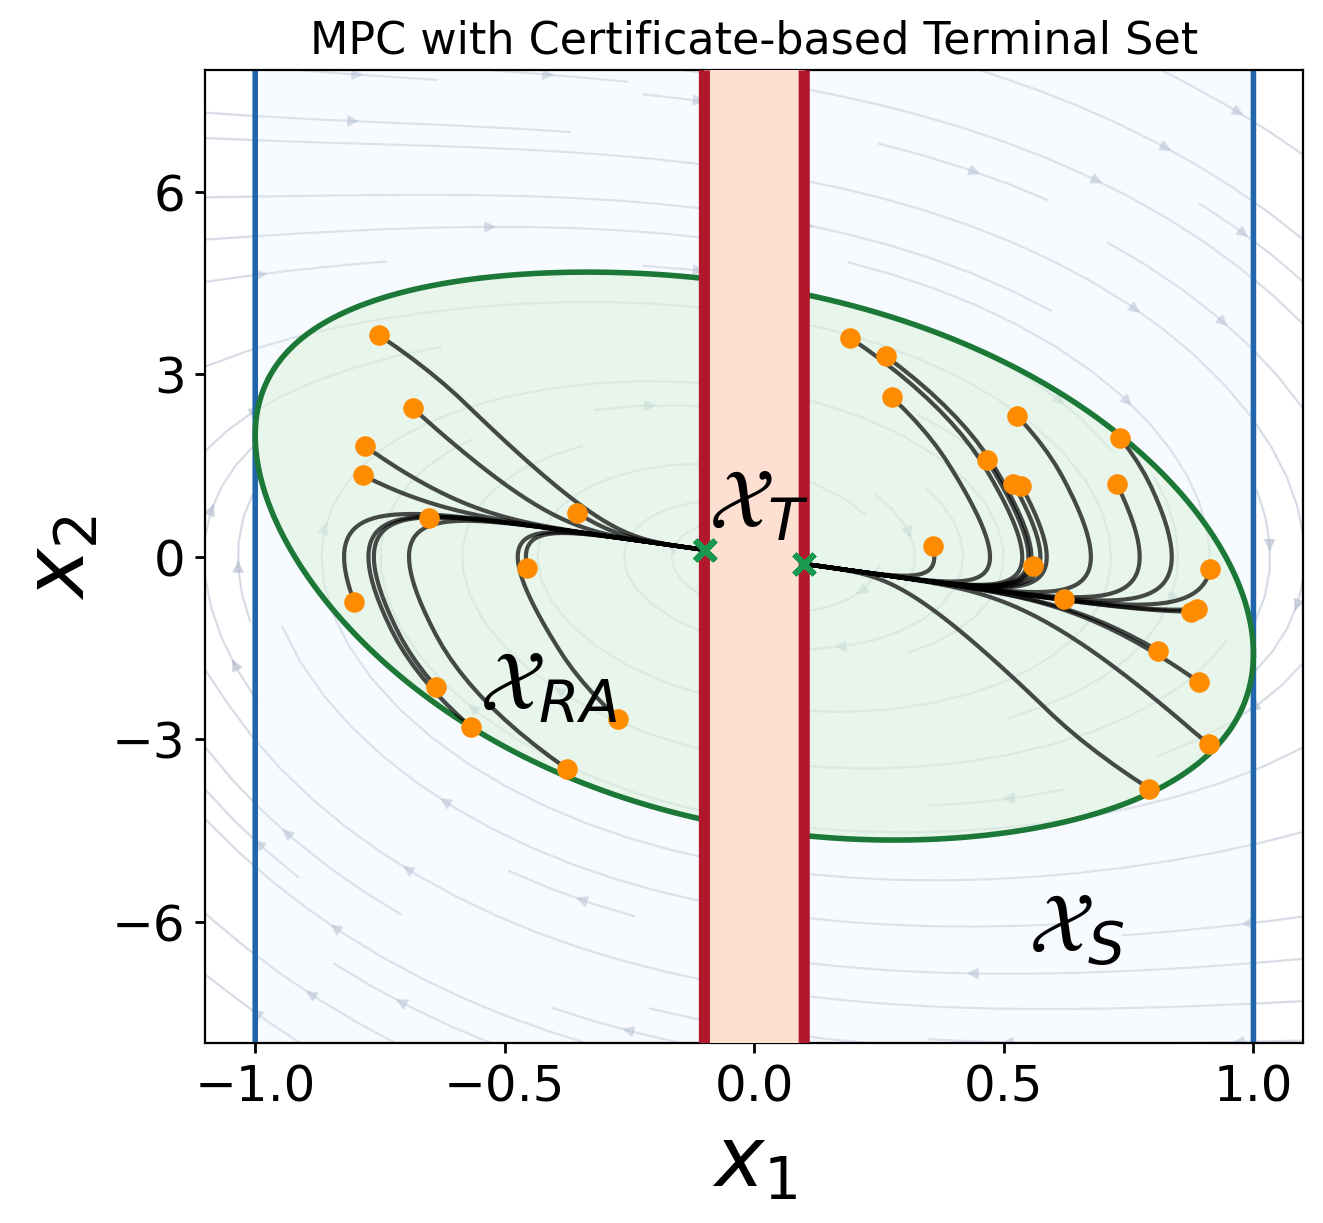

In [120]:
# ── Phase portrait: safe set / target set / certificate / trajectories ───────
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px, 600 * px), layout="constrained")
fig.set_dpi(200)

# Evaluation grid
nx1_grid = np.linspace(-1.1, 1.1, 1000)
nx2_grid = np.linspace(-8.0, 8.0, 1000)
X1g, X2g = np.meshgrid(nx1_grid, nx2_grid)

psi_fx = sp.lambdify([x1_sym, x2_sym], safe_set_x_sym, "numpy")
phi_fx = sp.lambdify([x1_sym, x2_sym], target_set_x_sym, "numpy")
Z_psi = psi_fx(X1g, X2g)
Z_phi = phi_fx(X1g, X2g)
Z_cert = certificate_func(X1g, X2g)

# ── Closed-loop vector field (background) ────────────────────────────────────
vf_x1 = np.linspace(-1.1, 1.1, 28)
vf_x2 = np.linspace(-8.0, 8.0, 28)
VF_X1, VF_X2 = np.meshgrid(vf_x1, vf_x2)

closed_loop_sym = f_sym + g_sym @ u_opt_sym
dyn_cl_f = sp.lambdify([x1_sym, x2_sym], closed_loop_sym, "numpy")
VF_dyn = np.array(dyn_cl_f(VF_X1, VF_X2)).squeeze()
ax.streamplot(
    vf_x1,
    vf_x2,
    VF_dyn[0],
    VF_dyn[1],
    density=0.8,
    color=BetterColor.gray0(0.5),
    linewidth=0.8,
    arrowsize=0.8,
    zorder=0,
)

# ── Safe set ─────────────────────────────────────────────────────────────────
ax.contourf(
    X1g, X2g, Z_psi, levels=[0, np.inf], colors=["#e6f2ff"], alpha=0.3, zorder=1
)
ax.contour(X1g, X2g, Z_psi, levels=[0], colors=["#2166ac"], linewidths=2, zorder=2)

# ── Target set ───────────────────────────────────────────────────────────────
ax.contourf(
    X1g, X2g, Z_phi, levels=[-np.inf, 0], colors=["#fee0d2"], alpha=1, zorder=100
)
ax.contour(X1g, X2g, Z_phi, levels=[0], colors=["#b2182b"], linewidths=4, zorder=101)

# ── Certificate superlevel set ───────────────────────────────────────────────
ax.contourf(
    X1g, X2g, Z_cert, levels=[0, np.inf], colors=["#d9f0d9"], alpha=0.5, zorder=50
)
ax.contour(X1g, X2g, Z_cert, levels=[0], colors=["#1b7837"], linewidths=2, zorder=51)

# ── MPC trajectories ─────────────────────────────────────────────────────────
for this_traj in traj_x_mpc:
    if this_traj.shape[0] < 2:
        continue
    ax.plot(
        this_traj[:, 0],
        this_traj[:, 1],
        color="black",
        linestyle="-",
        linewidth=1.5,
        alpha=0.7,
        zorder=200,
    )
    ax.scatter(
        this_traj[0, 0],
        this_traj[0, 1],
        s=50,
        c=BetterColor.orange3(),
        marker="o",
        linewidths=0.3,
        zorder=300,
    )
    ax.scatter(
        this_traj[-1, 0],
        this_traj[-1, 1],
        s=50,
        c=BetterColor.green0(),
        marker="x",
        linewidths=2,
        zorder=300,
    )

this_fontsize = 30
ax.text(0.55, -6.5, r"$\mathcal{X}_S$", zorder=1000, fontsize=this_fontsize)
ax.text(-0.09, 0.5, r"$\mathcal{X}_T$", zorder=1000, fontsize=this_fontsize)
ax.text(-0.55, -2.5, r"$\mathcal{X}_{RA}$", zorder=1000, fontsize=this_fontsize)

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-8.0, 8.0)
ax.xaxis.set_tick_params(labelsize=18, width=1)
ax.yaxis.set_tick_params(labelsize=18, width=1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))
ax.set_xlabel("$x_1$", fontsize=this_fontsize)
ax.set_ylabel("$x_2$", fontsize=this_fontsize)
ax.set_title("MPC with Certificate-based Terminal Set", fontsize=16)
plt.show()

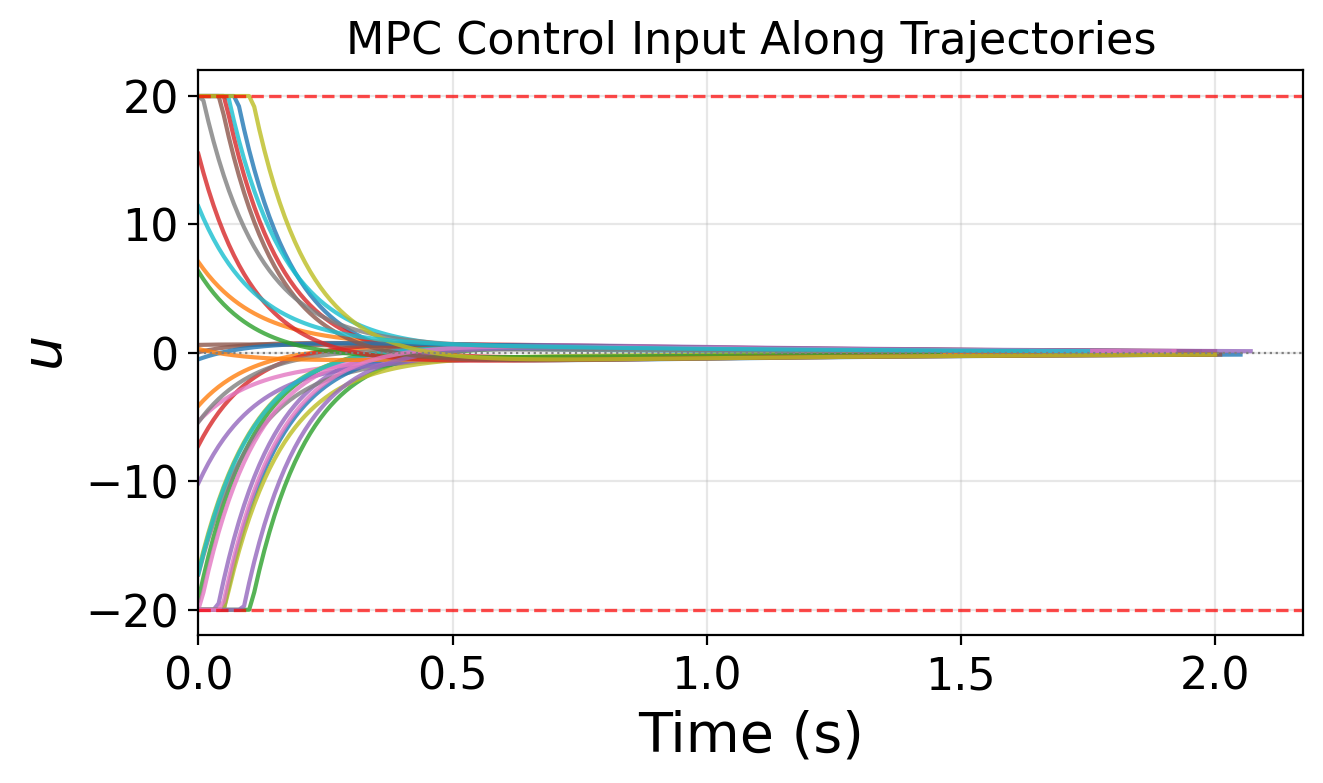

In [121]:
# ── Control input signals along MPC trajectories ────────────────────────────
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px, 380 * px), layout="constrained")
fig.set_dpi(200)

for i, (this_traj, this_u) in enumerate(zip(traj_x_mpc, traj_u_mpc)):
    if len(this_u) == 0:
        continue
    t_vals = np.arange(len(this_u)) * dt
    ax.plot(t_vals, this_u, linewidth=1.5, alpha=0.8)

ax.axhline(
    u_max,
    color="red",
    linewidth=1.2,
    linestyle="--",
    alpha=0.7,
    # label=f"$u_{{\\max}} = {u_max}$",
)
ax.axhline(-u_max, color="red", linewidth=1.2, linestyle="--", alpha=0.7)
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

ax.xaxis.set_tick_params(labelsize=16)
ax.yaxis.set_tick_params(labelsize=16)
ax.set_xlabel("Time (s)", fontsize=20)
ax.set_xlim(0, None)
ax.set_ylabel("$u$", fontsize=20)
ax.set_title("MPC Control Input Along Trajectories", fontsize=16)
# ax.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()